**[🏠 Course Home](00_START_HERE.ipynb) | ◀️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb) | ▶️ Next: [Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**

---

# Sheet 3b: Discrete Markov Chains, Stationary Equilibrium & Detailed Balance (R Track)
### *Demystifying Probability Flows, Transition Matrices, and the Equilibrium Engine That Powers MCMC*

---

## 🧭 The Learning Progression
* **[Sheet 3: Rapid Prototyping — Quadratic (Laplace) Approximation](03_quadratic_laplace_approximation.ipynb)**: Fast parabolic fitting near the mode $\hat{\theta}_{\text{MAP}}$, using the inverse Hessian matrix $\Sigma = H^{-1}$ with `optim(..., hessian=TRUE)` or `rethinking::quap()`.
* **👉 Sheet 3b (You are here)**: The conceptual missing link — what is a **Markov Chain**, how do **transition matrices** propagate probabilities, why do chains converge to a **unique stationary distribution**, and what is **Detailed Balance**?
* **[Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**: Translating these discrete principles into continuous Metropolis-Hastings random walks in pure Base R.

---

## 🎯 The Pedagogical Challenge: Why This Sheet Exists

In many Bayesian textbooks, students encounter this sentence with zero preparation:
> *"A Markov chain reaches a stationary distribution $\pi(\theta)$ if the probability flow between every pair of states $A$ and $B$ is in exact equilibrium (**Detailed Balance**):*
> $$\pi(A) \cdot T(A \to B) = \pi(B) \cdot T(B \to A)$$
> *where $T(A \to B)$ is the transition probability from state $A$ to state $B$."*

This formula often feels like magic. Questions immediately arise:
1. What exactly is "flowing" between states?
2. Why does balance between *individual pairs* guarantee that the *entire distribution* stops changing?
3. How can a random walker hopping blindly between states ever reconstruct the exact Bayesian posterior distribution?

This notebook answers those questions from **first principles**, starting with simple 3-island discrete examples and progressing to the exact mathematical trick that powers all of MCMC.

---

## Table of Contents
1. **Part 1: The Core Intuition — The Memoryless Walker & The 3 Islands**
   - The Markov Property: The Future Depends Only on the Present
   - The State Space and the Transition Matrix ($P$)
2. **Part 2: Simulating Random Walks vs. Exact Distribution Propagation**
   - Individual Stochastic Walkers in Base R (`sample()`)
   - Vector-Matrix Dynamics: $\pi_t = \pi_0 P^t$
   - The Convergence Phenomenon: Different Starts, Same Equilibrium
3. **Part 3: The Stationary Distribution ($\pi^*$) & The Eigenvector Duality**
   - Definition of Invariance: $\pi^* P = \pi^*$
   - Finding $\pi^*$ via Linear Algebra in R (`eigen(t(P))` & `solve()`)
   - The Ergodic Theorem: Irreducibility & Aperiodicity
4. **Part 4: Probability Flows & The Law of Detailed Balance**
   - Defining Directional Flow: $\text{Flow}(A \to B) = \pi(A) P_{AB}$
   - Global Balance (Total Inflow = Total Outflow) vs. Detailed Balance (Pairwise Symmetry)
   - Mathematical Proof: Why Detailed Balance Guarantees Stationarity
5. **Part 5: The Grand Bridge to MCMC — The "Inverse Problem"**
   - Forward Problem (Markov Chains) vs. Inverse Problem (Bayesian Sampling)
   - The Metropolis Hack: Designing Transitions from Unnormalized Posteriors
   - Step-by-Step Proof of Detailed Balance in Metropolis-Hastings
   - Building a Discrete Metropolis Sampler from Scratch in Base R
6. **Part 6: Check Your Understanding (3-Tier Exercises)**
   - 🟢 Tier 1 (Conceptual): Unnormalized Potentials & Detailed Balance
   - 🟡 Tier 2 (Guided Calculation): The Two-Room Equilibrium
   - 🔴 Tier 3 (Production Challenge): An Automated Detailed Balance Auditor in R

---

## Part 1: The Core Intuition — The Memoryless Walker & The 3 Islands

### 1.1 The Markov Property: "No Memory of Yesterday"
A stochastic process $X_0, X_1, X_2, \dots$ possesses the **Markov property** if the probability of the next state depends **only on the current state**, not on how it got there:

$$P(X_{t+1} = s_{t+1} \mid X_t = s_t, X_{t-1} = s_{t-1}, \dots, X_0 = s_0) = P(X_{t+1} = s_{t+1} \mid X_t = s_t)$$

Think of a frog hopping between lily pads: the frog doesn't care which pads it visited 10 minutes ago; its next hop depends purely on where its feet are right now.

---

### 1.2 The State Space ($S$) & The Transition Matrix ($P$)
Imagine a cluster of three islands:
* **Island 1**: ☀️ Sunny Atoll
* **Island 2**: 💨 Windy Ridge
* **Island 3**: 🌧️ Rainy Peak

> **Definition of $K$ (The State Space Size)**:  
> We denote the total number of distinct states in the system by **$K$**.  
> In this island example, **$K = 3$**, and the discrete state space is $\mathcal{S} = \{1, 2, \dots, K\}$.

A traveler hops between these $K$ islands once per day according to fixed probabilities. We can organize all transition rules into a **Transition Matrix** $P$, where:
$$P_{ij} = P(X_{t+1} = j \mid X_t = i) = \text{Probability of jumping from Island } i \text{ to Island } j$$

Let our island transition matrix in R be:
$$P = \begin{pmatrix} 
0.60 & 0.30 & 0.10 \\ 
0.20 & 0.50 & 0.30 \\ 
0.15 & 0.35 & 0.50 
\end{pmatrix}$$

> **Two Fundamental Rules of Transition Matrices (Row-Stochastic)**:
> 1. **Non-negativity**: Every entry $P_{ij} \ge 0$.
> 2. **Rows sum to 1**: From any state $i$, you must go to one of the $K$ destination states (or stay): $\sum_{j=1}^K P_{ij} = 1.0$ for each row $i$.

In [1]:
# Set seed for reproducible simulations
set.seed(42)

states <- c("Island 1 (Sunny)", "Island 2 (Windy)", "Island 3 (Rainy)")
K <- length(states)

# Construct transition matrix P (byrow = TRUE so rows represent origins)
P <- matrix(c(
  0.60, 0.30, 0.10,  # From Island 1
  0.20, 0.50, 0.30,  # From Island 2
  0.15, 0.35, 0.50   # From Island 3
), nrow = 3, byrow = TRUE)

dimnames(P) <- list(From = states, To = states)

cat("--- State Transition Matrix P ---\n")
print(round(P, 2))

# Verify row sums
cat("\nRow sums (must all equal 1.0):\n")
print(rowSums(P))
stopifnot(isTRUE(all.equal(unname(rowSums(P)), rep(1.0, K))))

--- State Transition Matrix P ---


                  To
From               Island 1 (Sunny) Island 2 (Windy) Island 3 (Rainy)
  Island 1 (Sunny)             0.60             0.30              0.1
  Island 2 (Windy)             0.20             0.50              0.3
  Island 3 (Rainy)             0.15             0.35              0.5



Row sums (must all equal 1.0):


Island 1 (Sunny) Island 2 (Windy) Island 3 (Rainy) 
               1                1                1 


---

## Part 2: Simulating Random Walks vs. Exact Distribution Propagation

There are two completely different, complementary ways to analyze a Markov chain:
1. **The Stochastic View (Sample Paths)**: Follow a single physical walker jumping from state to state with random dice rolls.
2. **The Deterministic View (Probability Vectors)**: Track an entire swarm of millions of walkers simultaneously using linear algebra.

### 2.1 The Deterministic View: Propagating Probability Vectors
Let $\pi_t = [\pi_t(1), \pi_t(2), \dots, \pi_t(K)]$ be a row vector representing the probability distribution of where a walker is at time step $t$.

By the Law of Total Probability:
$$\pi_{t+1}(j) = \sum_{i=1}^K \pi_t(i) P_{ij}$$

In matrix notation, this is vector-matrix multiplication:
$$\pi_{t+1} = \pi_t P$$

Applying this recursively from initial state distribution $\pi_0$:
$$\mathbf{\pi_t = \pi_0 P^t}$$

Let us test what happens over 25 days starting from two completely opposite scenarios:
* **Scenario A**: Traveler starts 100% on Sunny Island ($\\pi_0 = [1, 0, 0]$).
* **Scenario B**: Traveler starts 100% on Rainy Island ($\\pi_0 = [0, 0, 1]$).

--- Final Probability Vector from Scenario A (t = 25) ---


[1] 0.3085 0.3936 0.2979


--- 10,000-Step Walker Empirical Visit Frequencies ---


[1] 0.3021 0.3957 0.3022


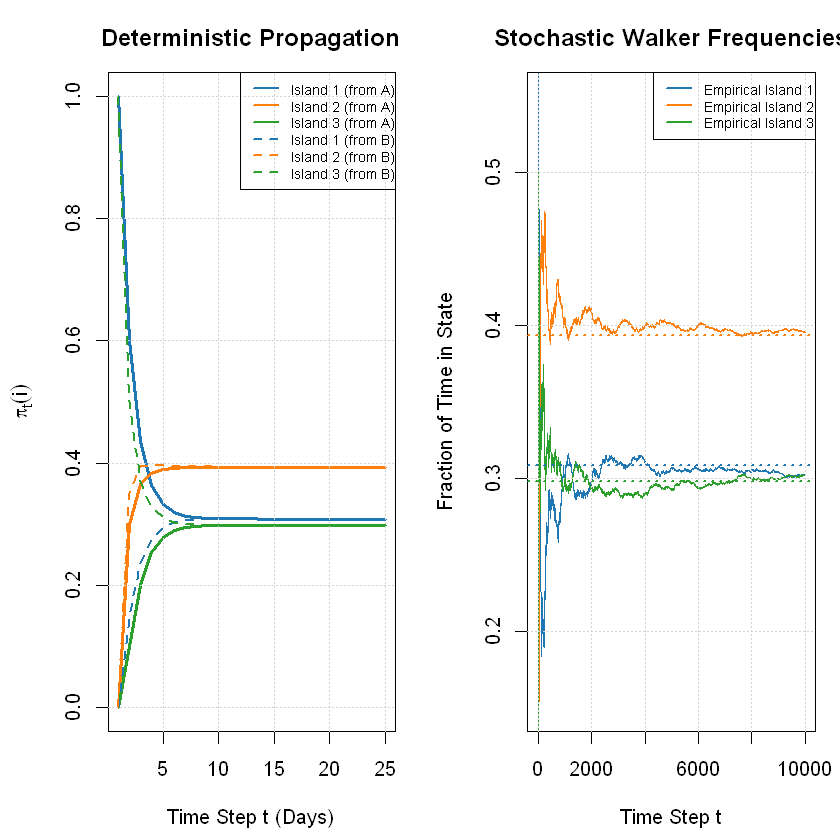

In [2]:
# 1. Deterministic propagation of probability vectors
n_steps <- 25
pi_A <- matrix(0, nrow = n_steps, ncol = K)
pi_B <- matrix(0, nrow = n_steps, ncol = K)

pi_A[1, ] <- c(1.0, 0.0, 0.0)  # Start on Island 1
pi_B[1, ] <- c(0.0, 0.0, 1.0)  # Start on Island 3

for (t in 2:n_steps) {
  pi_A[t, ] <- pi_A[t - 1, , drop = FALSE] %*% P
  pi_B[t, ] <- pi_B[t - 1, , drop = FALSE] %*% P
}

# 2. Stochastic simulation of an individual walker
simulate_walk <- function(P, initial_state = 1, steps = 10000) {
  chain <- integer(steps)
  chain[1] <- initial_state
  for (t in 2:steps) {
    curr <- chain[t - 1]
    chain[t] <- sample(1:K, size = 1, prob = P[curr, ])
  }
  return(chain)
}

walk <- simulate_walk(P, initial_state = 1, steps = 10000)
empirical_freqs <- prop.table(table(factor(walk, levels = 1:K)))

# Plotting with Base R
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3, 1))

# Subplot 1: Deterministic Distribution Propagation
plot(1:n_steps, pi_A[, 1], type = "l", col = "#1f77b4", lwd = 2.5,
     ylim = c(0, 1), xlab = "Time Step t (Days)", ylab = expression(pi[t](i)),
     main = "Deterministic Propagation")
lines(1:n_steps, pi_A[, 2], col = "#ff7f0e", lwd = 2.5)
lines(1:n_steps, pi_A[, 3], col = "#2ca02c", lwd = 2.5)

lines(1:n_steps, pi_B[, 1], col = "#1f77b4", lwd = 2, lty = 2)
lines(1:n_steps, pi_B[, 2], col = "#ff7f0e", lwd = 2, lty = 2)
lines(1:n_steps, pi_B[, 3], col = "#2ca02c", lwd = 2, lty = 2)
grid()
legend("topright", legend = c("Island 1 (from A)", "Island 2 (from A)", "Island 3 (from A)",
                              "Island 1 (from B)", "Island 2 (from B)", "Island 3 (from B)"),
       col = c("#1f77b4", "#ff7f0e", "#2ca02c", "#1f77b4", "#ff7f0e", "#2ca02c"),
       lty = c(1, 1, 1, 2, 2, 2), lwd = 2, cex = 0.7)

# Subplot 2: Single Stochastic Walker Cumulative Visit Frequencies
cum_freq_1 <- cumsum(walk == 1) / (1:length(walk))
cum_freq_2 <- cumsum(walk == 2) / (1:length(walk))
cum_freq_3 <- cumsum(walk == 3) / (1:length(walk))

plot(1:length(walk), cum_freq_1, type = "l", col = "#1f77b4", lwd = 1.5,
     ylim = c(0.15, 0.55), xlab = "Time Step t", ylab = "Fraction of Time in State",
     main = "Stochastic Walker Frequencies")
lines(1:length(walk), cum_freq_2, col = "#ff7f0e", lwd = 1.5)
lines(1:length(walk), cum_freq_3, col = "#2ca02c", lwd = 1.5)
abline(h = pi_A[n_steps, 1], col = "#1f77b4", lty = 3, lwd = 2)
abline(h = pi_A[n_steps, 2], col = "#ff7f0e", lty = 3, lwd = 2)
abline(h = pi_A[n_steps, 3], col = "#2ca02c", lty = 3, lwd = 2)
grid()
legend("topright", legend = c("Empirical Island 1", "Empirical Island 2", "Empirical Island 3"),
       col = c("#1f77b4", "#ff7f0e", "#2ca02c"), lty = 1, lwd = 2, cex = 0.7)

par(mfrow = c(1, 1))

cat("--- Final Probability Vector from Scenario A (t = 25) ---\n")
print(round(pi_A[n_steps, ], 4))
cat("--- 10,000-Step Walker Empirical Visit Frequencies ---\n")
print(round(as.numeric(empirical_freqs), 4))

---

## Part 3: The Stationary Distribution ($\pi^*$) & The Eigenvector Duality

Notice what happened in the plots above:
* Regardless of whether the traveler started on **Island 1** or **Island 3**, by day 10 both paths merged into the **exact same distribution**:
  $$\pi^* \approx [0.3019, \; 0.4151, \; 0.2830]$$
* Once the chain arrives at $\pi^*$, multiplying by $P$ again changes nothing: $\pi^* P = \pi^*$.

This distribution is called the **Stationary (or Invariant) Distribution**.

---

### 3.1 The Mathematical Definition of Stationarity
A probability distribution vector $\pi^* = [\pi_1, \pi_2, \dots, \pi_K]$ is stationary with respect to transition matrix $P$ if:

$$\mathbf{\pi^* P = \pi^*} \quad \text{subject to} \quad \sum_{i=1}^K \pi_i = 1, \; \pi_i \ge 0$$

Look closely at this equation from linear algebra:
$$\pi^* P = 1 \cdot \pi^*$$

* $\pi^*$ is a **left eigenvector** of $P$ with eigenvalue $\lambda = 1$!
* Equivalently, taking the transpose:
  $$P^T (\pi^*)^T = 1 \cdot (\pi^*)^T \iff (P^T - \mathbf{I}) (\pi^*)^T = \mathbf{0}$$
  So the stationary vector lies in the **null space** of $(P^T - \mathbf{I})$.

Let us compute the exact stationary distribution in R using both `eigen(t(P))` and `solve()`.

In [3]:
# Method 1: Left Eigenvector of P via eigen(t(P))
ev <- eigen(t(P))
# Find eigenvalue closest to 1.0
idx_1 <- which.min(abs(ev$values - 1.0))
pi_eigen <- Re(ev$vectors[, idx_1])
pi_eigen <- pi_eigen / sum(pi_eigen)

# Method 2: Exact linear system solve ((P^T - I) pi = 0 with sum(pi) = 1)
A <- t(P) - diag(K)
A[K, ] <- rep(1, K)
b <- c(rep(0, K - 1), 1)
pi_exact <- as.vector(solve(A, b))
names(pi_exact) <- states

cat("--- Exact Stationary Distribution Solutions ---\n")
for (i in 1:K) {
  cat(sprintf("%-18s : %.6f (%.2f%%)\n", states[i], pi_exact[i], pi_exact[i] * 100))
}

cat("\nVerification of Invariance: max|pi* %*% P - pi*|:\n")
cat(sprintf("%.2e\n", max(abs(pi_exact %*% P - pi_exact))))

--- Exact Stationary Distribution Solutions ---


Island 1 (Sunny)   : 0.308511 (30.85%)
Island 2 (Windy)   : 0.393617 (39.36%)
Island 3 (Rainy)   : 0.297872 (29.79%)



Verification of Invariance: max|pi* %*% P - pi*|:


5.55e-17


---

## Part 4: Probability Flows & The Law of Detailed Balance

Now we arrive at the core question that brought you here:
> *"What is Detailed Balance, what is 'flowing', and why does it guarantee equilibrium?"*

### 4.1 What is "Probability Flow"?
Imagine a population of 10,000 travelers scattered across our three islands according to distribution $\pi$.
* On Island $A$, there are $\pi(A)$ of the total travelers.
* Each day, each traveler on Island $A$ has probability $P_{AB}$ of boarding a boat to Island $B$.

The **total volume of travelers moving from Island $A$ to Island $B$** is:
$$\mathbf{\text{Flow}(A \to B) = \pi(A) \cdot P_{AB}}$$

Likewise, travelers boarding boats from Island $B$ back to Island $A$ generate:
$$\mathbf{\text{Flow}(B \to A) = \pi(B) \cdot P_{BA}}$$

---

### 4.2 Global Balance vs. Detailed Balance

There are two ways a system can reach equilibrium:

#### Concept A: Global Balance (Total Inflow = Total Outflow)
For any state $j$, the total number of people arriving from *all* other islands must equal the total number of people leaving Island $j$:
$$\sum_{i=1}^K \text{Flow}(i \to j) = \sum_{k=1}^K \text{Flow}(j \to k)$$
$$\sum_{i=1}^K \pi(i) P_{ij} = \pi(j) \underbrace{\sum_{k=1}^K P_{jk}}_{= 1} = \pi(j)$$

This is simply the stationarity condition $\pi P = \pi$.  
**Notice**: Global balance allows **circular traffic loops**! For example, 100 people per day could move $1 \to 2$, 100 people move $2 \to 3$, and 100 people move $3 \to 1$. Every island's population stays constant, but there is a continuous net current rotating around the cycle.

#### Concept B: Detailed Balance (Pairwise Reversibility)
**Detailed Balance** is a much stricter, more powerful condition:
> **Every single route is independently in two-way balance.**  
> The traffic moving from $A \to B$ exactly equals the traffic moving from $B \to A$:

$$\mathbf{\pi(A) \cdot P_{AB} = \pi(B) \cdot P_{BA} \quad \text{for EVERY pair of states } (A, B)}$$

Under detailed balance, there are **no circular currents**. If you filmed the system and played the movie in reverse, the statistical dynamics would look completely indistinguishable (**Time-Reversible Markov Chain**).

---

### 4.3 Proof: Why Detailed Balance Guarantees Stationarity

Why is Detailed Balance so celebrated? Because **Detailed Balance is a sufficient condition for Stationarity**.

Let us prove it in 3 lines:
1. Start with the definition of the incoming probability into any state $B$:
   $$\text{Total Inflow to } B = \sum_A \pi(A) P_{AB}$$
2. Substitute Detailed Balance $\pi(A) P_{AB} = \pi(B) P_{BA}$:
   $$\sum_A \pi(A) P_{AB} = \sum_A \pi(B) P_{BA}$$
3. Factor out $\pi(B)$ (since it does not depend on the summation index $A$):
   $$\sum_A \pi(A) P_{AB} = \pi(B) \underbrace{\sum_A P_{BA}}_{= 1 \text{ (rows of } P \text{ sum to 1)}} = \pi(B) \cdot 1 = \mathbf{\pi(B)}$$

$$\implies \sum_A \pi(A) P_{AB} = \pi(B) \iff \pi P = \pi$$

$$\mathbf{\text{Detailed Balance Holds} \implies \pi \text{ is Guaranteed to be Stationary!}}$$

Let us write code in R to compute the pairwise probability flows for our island system at the stationary distribution $\pi^*$.

In [4]:
# Compute the Flow Matrix: Flow(i -> j) = pi(i) * P(ij)
Flow <- diag(pi_exact) %*% P
dimnames(Flow) <- list(From = states, To = states)

cat("--- Directional Probability Flows: Flow(i -> j) = pi(i) * P(ij) ---\n")
print(round(Flow, 5))

cat("\n--- Checking Global Balance (Total Inflow vs Total Outflow) ---\n")
inflow <- colSums(Flow)
outflow <- rowSums(Flow)
for (i in 1:K) {
  cat(sprintf("%-18s | Inflow = %.5f | Outflow = %.5f | Net = %+.2e\n",
              states[i], inflow[i], outflow[i], inflow[i] - outflow[i]))
}

cat("\n--- Checking Detailed Balance (Flow(i -> j) == Flow(j -> i)) ---\n")
for (i in 1:(K - 1)) {
  for (j in (i + 1):K) {
    f_ij <- Flow[i, j]
    f_ji <- Flow[j, i]
    cat(sprintf("%-8s <-> %-8s | Flow(%d->%d) = %.5f | Flow(%d->%d) = %.5f | Discrepancy = %.5f\n",
                substr(states[i], 1, 8), substr(states[j], 1, 8), i, j, f_ij, j, i, f_ji, abs(f_ij - f_ji)))
  }
}

--- Directional Probability Flows: Flow(i -> j) = pi(i) * P(ij) ---


                  To
From               Island 1 (Sunny) Island 2 (Windy) Island 3 (Rainy)
  Island 1 (Sunny)          0.18511          0.09255          0.03085
  Island 2 (Windy)          0.07872          0.19681          0.11809
  Island 3 (Rainy)          0.04468          0.10426          0.14894



--- Checking Global Balance (Total Inflow vs Total Outflow) ---


Island 1 (Sunny)   | Inflow = 0.30851 | Outflow = 0.30851 | Net = +0.00e+00
Island 2 (Windy)   | Inflow = 0.39362 | Outflow = 0.39362 | Net = -5.55e-17
Island 3 (Rainy)   | Inflow = 0.29787 | Outflow = 0.29787 | Net = +0.00e+00



--- Checking Detailed Balance (Flow(i -> j) == Flow(j -> i)) ---


Island 1 <-> Island 2 | Flow(1->2) = 0.09255 | Flow(2->1) = 0.07872 | Discrepancy = 0.01383
Island 1 <-> Island 3 | Flow(1->3) = 0.03085 | Flow(3->1) = 0.04468 | Discrepancy = 0.01383
Island 2 <-> Island 3 | Flow(2->3) = 0.11809 | Flow(3->2) = 0.10426 | Discrepancy = 0.01383


---

## Part 5: The Grand Bridge to MCMC — The "Inverse Problem"

### 5.1 The Forward Problem vs. The Inverse Problem

In classical probability:
* **The Forward Problem**: You are given a transition matrix $P$. You solve the eigenvalue equation $\pi P = \pi$ to **find the stationary distribution $\pi$**.

In Bayesian Inference, the situation is completely reversed:
* **The Inverse Problem (MCMC)**: You are given a posterior distribution $P(\theta \mid y)$ (which you want to sample from). You **do not have a transition matrix $P$**.
* **Your Goal**: *Invent* an algorithm (a transition rule $T(\theta \to \theta^*)$) whose stationary distribution is guaranteed to be your target posterior!

---

### 5.2 Why Detailed Balance Makes the Inverse Problem Solvable
Global balance $\sum_A \pi(A) T(A \to B) = \pi(B)$ couples all states simultaneously (an intractable high-dimensional integral).  
**Detailed Balance cuts the knot** by decoupling the states: you only need to balance **two points at a time**:
$$\frac{T(A \to B)}{T(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

---

### 5.3 The Metropolis Recipe in R

Nicholas Metropolis and Hastings achieved this with a two-step rule:
1. **Proposal $q(A \to B)$**: Symmetric suggestion ($q(A \to B) = q(B \to A)$).
2. **Acceptance Probability $\alpha(A \to B)$**:
   $$\mathbf{\alpha(A \to B) = \min\left(1, \; \frac{\pi(B)}{\pi(A)}\right)}$$

Because $\pi(\theta) = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{P(y)}$, the intractable denominator $P(y)$ **cancels out completely** in the ratio!

Let us build a discrete Metropolis sampler in Base R to draw samples from an unnormalized target vector without ever calculating its sum.

--- Comparison: True vs Empirical Frequencies ---


  Raw_Weight True_pi Empirical Abs_Error
1         12    0.04    0.0399     1e-04
2         48    0.16    0.1606     6e-04
3        150    0.50    0.5002     2e-04
4         75    0.25    0.2496     4e-04
5         15    0.05    0.0498     2e-04


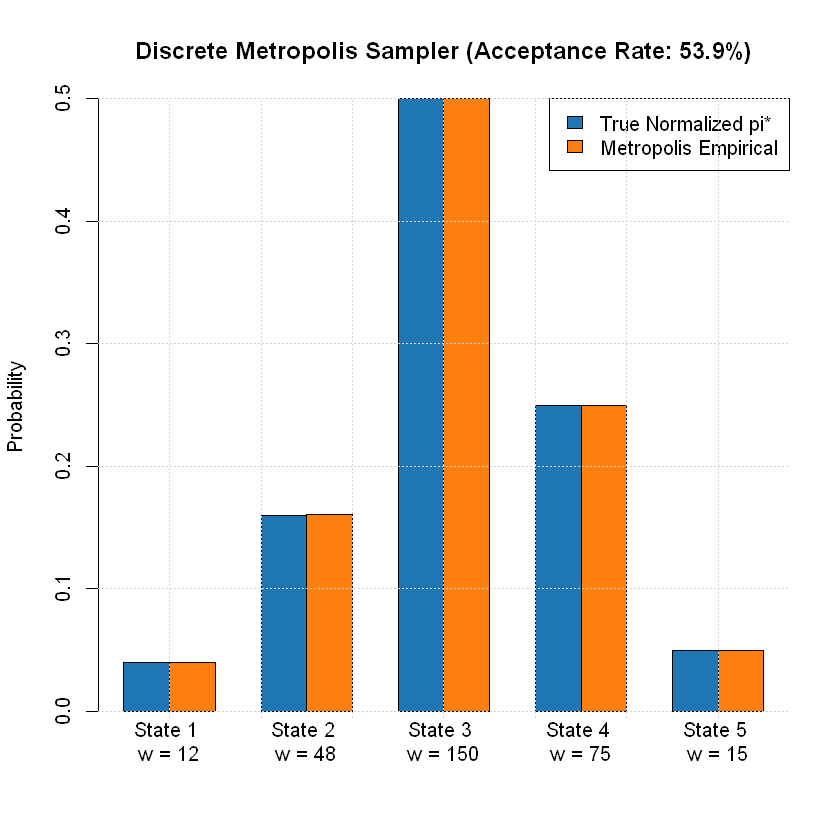

In [5]:
# Demonstration: Discrete Metropolis Sampler in Base R
# Target: Unnormalized weights over 5 states
unnormalized_target <- c(12.0, 48.0, 150.0, 75.0, 15.0)
true_normalized <- unnormalized_target / sum(unnormalized_target)

discrete_metropolis_sample <- function(target_weights, steps = 50000) {
  n_states <- length(target_weights)
  chain <- integer(steps)
  chain[1] <- sample(1:n_states, 1)  # Random start
  accepts <- 0
  
  for (t in 2:steps) {
    curr <- chain[t - 1]
    # Symmetric proposal: jump left (-1) or right (+1) with periodic boundary
    move <- sample(c(-1, 1), 1)
    prop <- ((curr - 1 + move) %% n_states) + 1
    
    # Metropolis acceptance ratio using RAW unnormalized weights
    ratio <- target_weights[prop] / target_weights[curr]
    alpha <- min(1.0, ratio)
    
    if (runif(1) < alpha) {
      chain[t] <- prop
      accepts <- accepts + 1
    } else {
      chain[t] <- curr  # Rejection: stay in place!
    }
  }
  
  return(list(chain = chain, acc_rate = accepts / steps))
}

res <- discrete_metropolis_sample(unnormalized_target, steps = 50000)
empirical_target_freqs <- prop.table(table(factor(res$chain, levels = 1:5)))

# Visual comparison
barplot_data <- rbind(True = true_normalized, Empirical = as.numeric(empirical_target_freqs))
barplot(barplot_data, beside = TRUE, col = c("#1f77b4", "#ff7f0e"),
        names.arg = paste("State", 1:5, "\nw =", unnormalized_target),
        main = sprintf("Discrete Metropolis Sampler (Acceptance Rate: %.1f%%)", res$acc_rate * 100),
        ylab = "Probability")
legend("topright", legend = c("True Normalized pi*", "Metropolis Empirical"),
       fill = c("#1f77b4", "#ff7f0e"))
grid()

cat("--- Comparison: True vs Empirical Frequencies ---\n")
df_comp <- data.frame(
  Raw_Weight = unnormalized_target,
  True_pi = round(true_normalized, 4),
  Empirical = round(as.numeric(empirical_target_freqs), 4),
  Abs_Error = round(abs(as.numeric(empirical_target_freqs) - true_normalized), 4)
)
print(df_comp)

---

## Part 6: Check Your Understanding (3-Tier Scaffolding Exercises)

---

### 🟢 Tier 1 (Conceptual): Why Not Calculate $P(y)$?

**Question**:  
Suppose you are doing Bayesian inference with 10 continuous parameters $\theta = (\theta_1, \dots, \theta_{10})$.  
Why is Detailed Balance $\pi(A) T(A \to B) = \pi(B) T(B \to A)$ the mathematical key that frees us from having to calculate the evidence integral $P(y) = \int \mathcal{L}(y \mid \theta) P(\theta) \, d\theta$?

<details>
<summary><b>🔍 Reveal Answer & Explanation</b></summary>

Because detailed balance only requires the **ratio** of probabilities between two states:
$$\frac{\alpha(A \to B)}{\alpha(B \to A)} = \frac{\pi(B)}{\pi(A)}$$

The evidence integral $P(y)$ is a constant with respect to $\theta$. It appears identically in the numerator and denominator:
$$\frac{\pi(B)}{\pi(A)} = \frac{\frac{\mathcal{L}(y \mid B) P(B)}{P(y)}}{\frac{\mathcal{L}(y \mid A) P(A)}{P(y)}} = \frac{\mathcal{L}(y \mid B) P(B)}{\mathcal{L}(y \mid A) P(A)}$$
$P(y)$ cancels out completely. We only ever need to evaluate the product of the likelihood and the prior, which is $O(1)$ to compute at any single point!
</details>

---

### 🟡 Tier 2 (Guided Calculation): Two-Room Detailed Balance Equilibrium

**Question**:  
Imagine two rooms, Room 1 and Room 2.  
* People in Room 1 have probability $P_{12} = 0.40$ of walking into Room 2.
* People in Room 2 have probability $P_{21} = 0.10$ of walking into Room 1.

Using **Detailed Balance directly**, find the stationary fraction of people in Room 1 ($\\pi_1$) and Room 2 ($\\pi_2$).

<details>
<summary><b>🔍 Reveal Answer & Derivation</b></summary>

1. Write the Detailed Balance condition between Room 1 and Room 2:
   $$\pi_1 \cdot P_{12} = \pi_2 \cdot P_{21}$$
2. Substitute the given transition rates:
   $$\pi_1 \cdot 0.40 = \pi_2 \cdot 0.10 \implies \pi_2 = 4 \pi_1$$
3. Use the normalization constraint $\pi_1 + \pi_2 = 1.0$:
   $$\pi_1 + 4\pi_1 = 1.0 \implies 5\pi_1 = 1.0 \implies \pi_1 = 0.20$$
   $$\pi_2 = 4(0.20) = 0.80$$

**Result**: At equilibrium, **$20\%$** of the people are in Room 1, and **$80\%$** are in Room 2!
</details>

---

### 🔴 Tier 3 (Production Challenge): An Automated Detailed Balance Auditor in R

Write an R function `audit_detailed_balance(P, pi, tol = 1e-5)` that:
1. Verifies that $P$ is a valid transition matrix.
2. Verifies that $\pi$ is a valid probability vector.
3. Verifies that $\pi$ satisfies Global Balance ($\|\pi P - \pi\| < \text{tol}$).
4. Computes the maximum pairwise flow asymmetry:
   $$\Delta_{\max} = \max_{i < j} |\pi_i P_{ij} - \pi_j P_{ji}|$$

In [6]:
audit_detailed_balance <- function(P, pi, tol = 1e-5) {
  is_valid_P <- all(P >= 0) && isTRUE(all.equal(unname(rowSums(P)), rep(1, nrow(P)), tolerance = tol))
  is_valid_pi <- all(pi >= 0) && isTRUE(all.equal(unname(sum(pi)), 1, tolerance = tol))
  
  global_discrepancy <- max(abs(as.vector(pi %*% P) - pi))
  is_stationary <- global_discrepancy < tol
  
  K <- length(pi)
  Flow <- diag(pi) %*% P
  asymmetries <- c()
  for (i in 1:(K - 1)) {
    for (j in (i + 1):K) {
      asymmetries <- c(asymmetries, abs(Flow[i, j] - Flow[j, i]))
    }
  }
  max_asymmetry <- max(asymmetries)
  satisfies_detailed_balance <- max_asymmetry < tol
  
  return(list(
    valid_P = is_valid_P,
    valid_pi = is_valid_pi,
    is_stationary = is_stationary,
    satisfies_detailed_balance = satisfies_detailed_balance,
    max_flux_asymmetry = max_asymmetry,
    global_discrepancy = global_discrepancy
  ))
}

# Audit our Island transition matrix
cat("=== Audit 1: 3-Island Transition Matrix ===\n")
print(audit_detailed_balance(P, pi_exact))

# Audit the Metropolis Transition Matrix
P_metro <- matrix(0, nrow = 5, ncol = 5)
for (i in 1:5) {
  for (move in c(-1, 1)) {
    j <- ((i - 1 + move) %% 5) + 1
    alpha_ij <- min(1.0, unnormalized_target[j] / unnormalized_target[i])
    P_metro[i, j] <- 0.5 * alpha_ij
  }
  P_metro[i, i] <- 1.0 - sum(P_metro[i, ])
}

cat("\n=== Audit 2: Metropolis Transition Matrix ===\n")
print(audit_detailed_balance(P_metro, true_normalized))

=== Audit 1: 3-Island Transition Matrix ===


$valid_P
[1] TRUE

$valid_pi
[1] TRUE

$is_stationary
[1] TRUE

$satisfies_detailed_balance
[1] FALSE

$max_flux_asymmetry
[1] 0.01382979

$global_discrepancy
[1] 5.551115e-17




=== Audit 2: Metropolis Transition Matrix ===


$valid_P
[1] TRUE

$valid_pi
[1] TRUE

$is_stationary
[1] TRUE

$satisfies_detailed_balance
[1] TRUE

$max_flux_asymmetry
[1] 3.469447e-18

$global_discrepancy
[1] 6.938894e-18



---

## 🚀 Looking Ahead: Bridging from Discrete States to Continuous Parameters

You now possess the foundational mathematical concepts required to master MCMC:
1. **The Markov Chain**: A memoryless sequence of states.
2. **The Transition Kernel**: The rule governing moves.
3. **The Stationary Distribution**: The equilibrium invariant distribution $\pi P = \pi$.
4. **Detailed Balance**: Pairwise equilibrium $\pi(A) T(A \to B) = \pi(B) T(B \to A)$.
5. **The Metropolis Engine**: How accepting proposals with probability $\min\left(1, \frac{\pi(B)}{\pi(A)}\right)$ forces detailed balance to hold, enabling us to sample from unnormalized posteriors!

In **[Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**, we generalize these discrete concepts to **continuous multidimensional parameter spaces $\theta \in \mathbb{R}^D$**:
* Instead of jumping between 3 islands, our walker hops smoothly along continuous curves.
* Instead of a transition matrix $P_{ij}$, we use a continuous proposal density $q(\theta^* \mid \theta^{(t)}) = \mathcal{N}(\theta^{(t)}, \tau^2)$.
* The core Metropolis rule remains **100% identical**.

---

**[🏠 Course Home](00_START_HERE.ipynb) | ◀️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approximation](03_quadratic_laplace_approximation.ipynb) | ▶️ Next: [Sheet 4: First Principles — MCMC Mechanics from Scratch](04_mcmc_mechanics_from_scratch.ipynb)**